# Encoder-Only Transformer for Relational Reasoning
### Array Element Ranking

**Contents**
1. Setup
2. Data loading & EDA
3. Baseline models (MLP / RNN / LSTM)
4. Transformer encoder from scratch
5. Attention visualization
6. Ablation studies
7. OOD evaluation
8. Summary


## 1 · Setup

In [1]:
import os

BASE = os.path.join(os.getcwd(), "ranking_project")
os.makedirs(f"{BASE}/data",        exist_ok=True)
os.makedirs(f"{BASE}/checkpoints", exist_ok=True)
print("BASE =", BASE)


BASE = /content/ranking_project


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math, json, time, os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")

# Global hyperparameters
SEQ_LEN    = 10
VOCAB      = 1000     # values ∈ [0, 999]
EMBED_DIM  = 64       # baseline embedding dim
HIDDEN_DIM = 128      # baseline hidden dim
D_MODEL    = 128      # transformer model dim
N_HEADS    = 4
N_LAYERS   = 2
D_FF       = 256
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 40
LR         = 1e-3
SEED       = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


PyTorch 2.11.0+cu128  |  Device: cuda


## 2 · Data Loading & EDA

In [3]:
CSV_PATH = os.path.join(os.getcwd(), "/content/ranking_dataset.csv")
df = pd.read_csv(CSV_PATH)
print("Shape  :", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape  : (10000, 20)
Columns: ['val_0', 'val_1', 'val_2', 'val_3', 'val_4', 'val_5', 'val_6', 'val_7', 'val_8', 'val_9', 'rank_0', 'rank_1', 'rank_2', 'rank_3', 'rank_4', 'rank_5', 'rank_6', 'rank_7', 'rank_8', 'rank_9']


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,542,67,876,414,26,335,620,924,950,113,5,1,7,4,0,3,6,8,9,2
1,378,14,210,954,231,572,315,295,567,706,5,0,1,9,2,7,4,3,6,8
2,749,876,73,111,899,213,541,769,287,219,6,8,0,1,9,2,5,7,4,3
3,372,880,475,329,733,564,739,376,632,10,2,9,4,1,7,5,8,3,6,0
4,186,822,577,519,707,123,143,294,693,677,2,9,5,4,8,0,1,3,7,6


In [4]:
val_cols  = [f"val_{i}"  for i in range(SEQ_LEN)]
rank_cols = [f"rank_{i}" for i in range(SEQ_LEN)]

X_all = df[val_cols].values.astype(np.int64)
y_all = df[rank_cols].values.astype(np.int64)

assert (np.sort(y_all, axis=1) == np.arange(SEQ_LEN)).all(), "Rank completeness failed"
for i in range(len(X_all)):
    assert (X_all[i][np.argsort(y_all[i])] == np.sort(X_all[i])).all()
print("Sanity checks passed ✓")
print(f"Value range : {X_all.min()} – {X_all.max()}")
print(f"Rank  range : {y_all.min()} – {y_all.max()}")


Sanity checks passed ✓
Value range : 0 – 999
Rank  range : 0 – 9


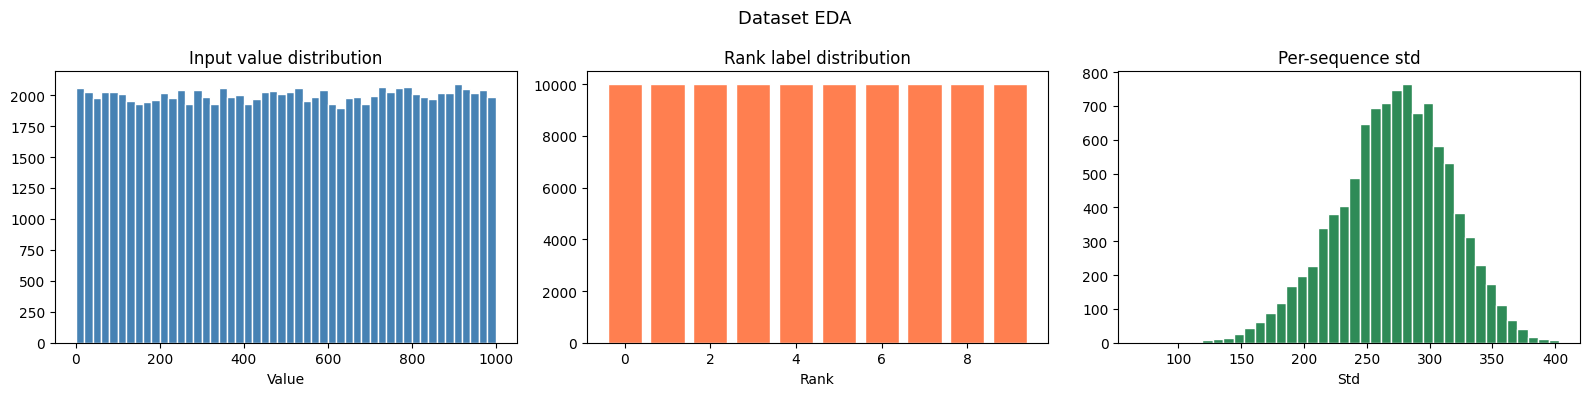

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(X_all.ravel(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Input value distribution"); axes[0].set_xlabel("Value")

rank_counts = np.bincount(y_all.ravel(), minlength=SEQ_LEN)
axes[1].bar(range(SEQ_LEN), rank_counts, color="coral", edgecolor="white")
axes[1].set_title("Rank label distribution"); axes[1].set_xlabel("Rank")

axes[2].hist(X_all.std(axis=1), bins=40, color="seagreen", edgecolor="white")
axes[2].set_title("Per-sequence std"); axes[2].set_xlabel("Std")

plt.suptitle("Dataset EDA", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "data", "eda.png"), dpi=120)
plt.show()


In [6]:
# ── Train / Val / Test split  80 / 10 / 10
idx     = np.random.permutation(len(X_all))
n_train = int(0.8 * len(idx))
n_val   = int(0.1 * len(idx))

X_train, y_train = X_all[idx[:n_train]],           y_all[idx[:n_train]]
X_val,   y_val   = X_all[idx[n_train:n_train+n_val]], y_all[idx[n_train:n_train+n_val]]
X_test,  y_test  = X_all[idx[n_train+n_val:]],     y_all[idx[n_train+n_val:]]

print(f"Train : {X_train.shape}  Val : {X_val.shape}  Test : {X_test.shape}")

for name, X, y in [("train",X_train,y_train),("val",X_val,y_val),("test",X_test,y_test)]:
    np.save(os.path.join(BASE, "data", f"X_{name}.npy"), X)
    np.save(os.path.join(BASE, "data", f"y_{name}.npy"), y)
print("Splits saved.")


Train : (8000, 10)  Val : (1000, 10)  Test : (1000, 10)
Splits saved.


In [7]:
# OOD sets
np.random.seed(99)

def make_ranks(X):
    return np.argsort(np.argsort(X, axis=1), axis=1).astype(np.int64)

ood_sets = {
    "ascending"   : np.tile(np.arange(1, SEQ_LEN+1),   (200,1)).astype(np.int64),
    "descending"  : np.tile(np.arange(SEQ_LEN, 0, -1), (200,1)).astype(np.int64),
    "large_values": np.random.randint(1000, 10000, (200, SEQ_LEN)).astype(np.int64),
    "negatives"   : np.random.randint(-1000, 0,    (200, SEQ_LEN)).astype(np.int64),
    "all_same"    : np.full((200, SEQ_LEN), 42, dtype=np.int64),
}
for name, X in ood_sets.items():
    y = make_ranks(X)
    np.save(os.path.join(BASE, "data", f"ood_{name}_X.npy"), X)
    np.save(os.path.join(BASE, "data", f"ood_{name}_y.npy"), y)
    print(f"  {name:15s}: {X.shape}")
print("OOD sets saved.")


  ascending      : (200, 10)
  descending     : (200, 10)
  large_values   : (200, 10)
  negatives      : (200, 10)
  all_same       : (200, 10)
OOD sets saved.


## 3 · Shared Utilities

In [8]:
def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.long),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train, y_train)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

def token_accuracy(logits, labels):
    return (logits.argmax(-1) == labels).float().mean().item()

def seq_accuracy(logits, labels):
    return (logits.argmax(-1) == labels).all(dim=1).float().mean().item()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot_loss = tot_tok = tot_seq = n = 0
    crit = nn.CrossEntropyLoss()
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        tot_loss += crit(logits.reshape(-1, SEQ_LEN), y.reshape(-1)).item() * X.size(0)
        tot_tok  += token_accuracy(logits, y) * X.size(0)
        tot_seq  += seq_accuracy(logits,  y) * X.size(0)
        n += X.size(0)
    return tot_loss/n, tot_tok/n, tot_seq/n

def train_loop(model, name="model", epochs=EPOCHS, lr=LR,
               tl=None, vl=None, use_scheduler=True):
    tl = tl or train_loader
    vl = vl or val_loader
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if use_scheduler else None
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_tok_acc": [], "val_seq_acc": []}
    t0   = time.time()
    for ep in range(1, epochs+1):
        model.train(); ep_loss = 0; n = 0
        for X, y in tl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(X).reshape(-1, SEQ_LEN), y.reshape(-1))
            loss.backward(); opt.step()
            ep_loss += loss.item() * X.size(0); n += X.size(0)
        if sch: sch.step()
        val_loss, val_tok, val_seq = evaluate(model, vl)
        hist["train_loss"].append(ep_loss/n)
        hist["val_loss"].append(val_loss)
        hist["val_tok_acc"].append(val_tok)
        hist["val_seq_acc"].append(val_seq)
        if ep % 10 == 0:
            print(f"[{name}] Ep {ep:3d}/{epochs} | "
                  f"train={ep_loss/n:.4f}  val={val_loss:.4f}  "
                  f"tok={val_tok:.3f}  seq={val_seq:.3f}")
    print(f"[{name}] Done in {time.time()-t0:.1f}s")
    return hist

def plot_histories(histories, title=""):
    """histories = dict of name → hist dict"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_loss"],  label=name)
        axes[1].plot(h["val_tok_acc"], label=name)
        axes[2].plot(h["val_seq_acc"], label=name)
    for ax, t in zip(axes, ["Train Loss", "Val Token Acc", "Val Seq Acc"]):
        ax.set_title(t); ax.legend(); ax.set_xlabel("Epoch"); ax.grid(alpha=.3)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

print("Utilities ready.")


Utilities ready.


## 4 · Baseline Models

### 4.1 · MLP


In [9]:
class MLPRanker(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, EMBED_DIM)
        self.net   = nn.Sequential(
            nn.Linear(SEQ_LEN * EMBED_DIM, HIDDEN_DIM * 2), nn.ReLU(),
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),           nn.ReLU(),
            nn.Linear(HIDDEN_DIM, SEQ_LEN * SEQ_LEN),
        )
    def forward(self, x):
        return self.net(self.embed(x).reshape(x.size(0), -1)).reshape(-1, SEQ_LEN, SEQ_LEN)

mlp = MLPRanker().to(DEVICE)
print(f"MLP params: {sum(p.numel() for p in mlp.parameters()):,}")
mlp_hist = train_loop(mlp, "MLP", use_scheduler=False)


MLP params: 273,892
[MLP] Ep  10/40 | train=1.2321  val=2.3348  tok=0.206  seq=0.000
[MLP] Ep  20/40 | train=0.4003  val=2.6313  tok=0.281  seq=0.000
[MLP] Ep  30/40 | train=0.1122  val=3.5090  tok=0.285  seq=0.000
[MLP] Ep  40/40 | train=0.0361  val=4.2834  tok=0.290  seq=0.000
[MLP] Done in 5.0s


### 4.2 · RNN


In [10]:
class RNNRanker(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, EMBED_DIM)
        self.rnn   = nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.head  = nn.Linear(HIDDEN_DIM, SEQ_LEN)
    def forward(self, x):
        out, _ = self.rnn(self.embed(x))
        return self.head(out)

rnn = RNNRanker().to(DEVICE)
print(f"RNN params: {sum(p.numel() for p in rnn.parameters()):,}")
rnn_hist = train_loop(rnn, "RNN", use_scheduler=False)


RNN params: 90,122
[RNN] Ep  10/40 | train=1.3554  val=1.3936  tok=0.406  seq=0.000
[RNN] Ep  20/40 | train=1.2358  val=1.3250  tok=0.436  seq=0.000
[RNN] Ep  30/40 | train=1.1926  val=1.3381  tok=0.433  seq=0.001
[RNN] Ep  40/40 | train=1.1501  val=1.3575  tok=0.429  seq=0.000
[RNN] Done in 5.4s


### 4.3 · LSTM


In [11]:
class LSTMRanker(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, EMBED_DIM)
        self.lstm  = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.head  = nn.Linear(HIDDEN_DIM, SEQ_LEN)
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.head(out)

lstm = LSTMRanker().to(DEVICE)
print(f"LSTM params: {sum(p.numel() for p in lstm.parameters()):,}")
lstm_hist = train_loop(lstm, "LSTM", use_scheduler=False)


LSTM params: 164,618
[LSTM] Ep  10/40 | train=1.2570  val=1.3279  tok=0.432  seq=0.000
[LSTM] Ep  20/40 | train=1.0934  val=1.3399  tok=0.429  seq=0.000
[LSTM] Ep  30/40 | train=0.9585  val=1.4396  tok=0.413  seq=0.000
[LSTM] Ep  40/40 | train=0.8244  val=1.5954  tok=0.395  seq=0.000
[LSTM] Done in 5.0s


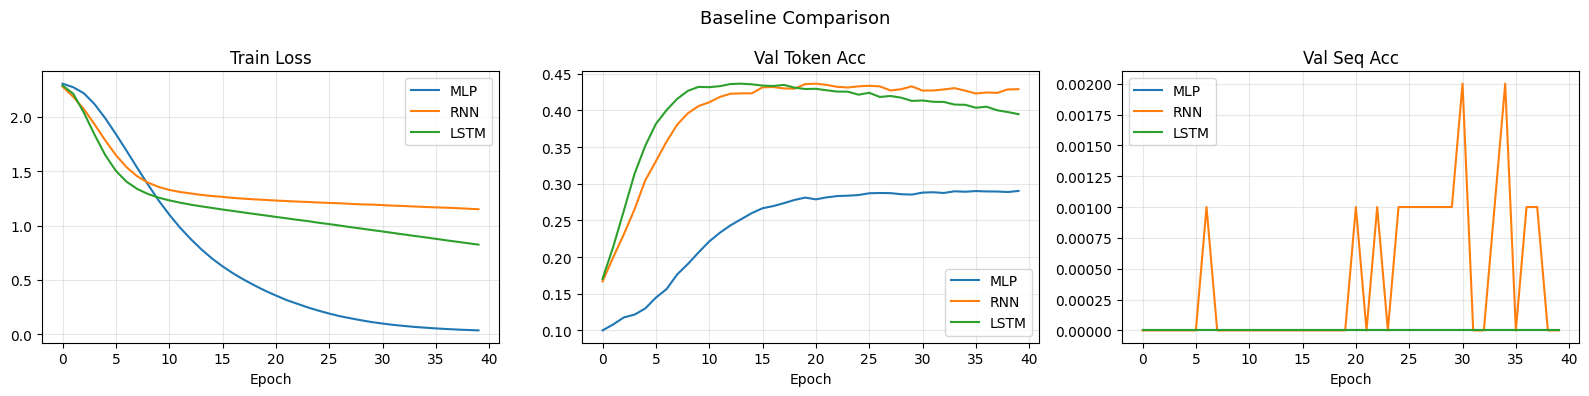

Model  |  test_loss |  tok_acc |  seq_acc
------------------------------------------
MLP    |     4.3401 |    0.279 |    0.000
RNN    |     1.3719 |    0.421 |    0.000
LSTM   |     1.6068 |    0.403 |    0.001


In [12]:
plot_histories({"MLP": mlp_hist, "RNN": rnn_hist, "LSTM": lstm_hist},
               title="Baseline Comparison")

print(f"{'Model':6s} | {'test_loss':>10} | {'tok_acc':>8} | {'seq_acc':>8}")
print("-" * 42)
baseline_results = {}
for name, model in [("MLP", mlp), ("RNN", rnn), ("LSTM", lstm)]:
    loss, tok, seq = evaluate(model, test_loader)
    baseline_results[name] = {"test_loss": loss, "tok_acc": tok, "seq_acc": seq}
    torch.save(model.state_dict(), os.path.join(BASE, "checkpoints", f"{name.lower()}.pt"))
    print(f"{name:6s} | {loss:>10.4f} | {tok:>8.3f} | {seq:>8.3f}")


## 5 · Encoder-Only Transformer from Scratch

### 5.1 · Architecture


In [13]:
# ── Sinusoidal Positional Encoding ────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, D)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


# ── Scaled Dot-Product Attention ──────────────────────────────────────────────
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V : (B, H, T, d_head)
    Returns : context (B, H, T, d_head),  weights (B, H, T, T)
    """
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights


# ── Multi-Head Attention ──────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    """
    Manually projects input into Q, K, V; splits into n_heads;
    runs attention per head; concatenates and projects back.
    """
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.d_model = d_model
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        def project_split(W):
            # (B,T,D) → (B,H,T,d_head)
            return W(x).reshape(B, T, self.n_heads, self.d_head).transpose(1, 2)
        Q, K, V  = project_split(self.W_q), project_split(self.W_k), project_split(self.W_v)
        ctx, w   = scaled_dot_product_attention(Q, K, V, mask)
        ctx      = ctx.transpose(1, 2).reshape(B, T, self.d_model)
        return self.W_o(ctx), w


# ── Feed-Forward Block ────────────────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


# ── Encoder Layer (Pre-LN) ────────────────────────────────────────────────────
class EncoderLayer(nn.Module):
    """Pre-LayerNorm: x → LN → MHA → +residual → LN → FFN → +residual"""
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.0):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads)
        self.ff    = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, w = self.attn(self.norm1(x), mask)
        x = x + self.drop(attn_out)
        x = x + self.drop(self.ff(self.norm2(x)))
        return x, w


# ── Full Transformer Ranker ───────────────────────────────────────────────────
class TransformerRanker(nn.Module):
    """
    Encoder-only transformer for token-level rank prediction.
    Input  : (B, T)    — integer token IDs
    Output : (B, T, T) — rank logits per token
    """
    def __init__(self, vocab=VOCAB, seq_len=SEQ_LEN, d_model=D_MODEL,
                 n_heads=N_HEADS, n_layers=N_LAYERS, d_ff=D_FF,
                 dropout=DROPOUT, use_pos_enc=True):
        super().__init__()
        self.use_pos_enc = use_pos_enc
        self.embed   = nn.Embedding(vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, seq_len)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, x, return_attn=False):
        e = self.embed(x)
        if self.use_pos_enc: e = self.pos_enc(e)
        ws = []
        for layer in self.layers:
            e, w = layer(e); ws.append(w)
        logits = self.head(self.norm(e))
        return (logits, ws) if return_attn else logits

model = TransformerRanker().to(DEVICE)
print(f"Transformer params: {sum(p.numel() for p in model.parameters()):,}")


Transformer params: 393,482


### 5.2 · Training

[Transformer] Ep  10/40 | train=0.7089  val=0.5507  tok=0.771  seq=0.072
[Transformer] Ep  20/40 | train=0.4650  val=0.3116  tok=0.874  seq=0.311
[Transformer] Ep  30/40 | train=0.3873  val=0.2724  tok=0.888  seq=0.327
[Transformer] Ep  40/40 | train=0.3716  val=0.2520  tok=0.898  seq=0.384
[Transformer] Done in 11.6s


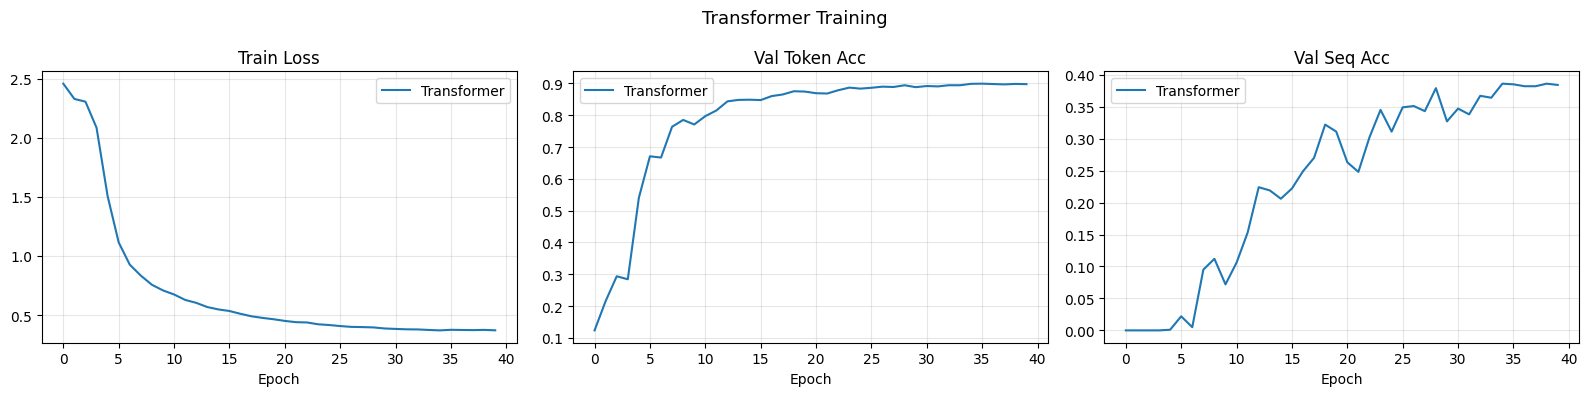


Test | loss=0.2541  tok_acc=0.8968  seq_acc=0.3790
Checkpoint saved.


In [14]:
transformer_hist = train_loop(model, "Transformer")
plot_histories({"Transformer": transformer_hist}, title="Transformer Training")

test_loss, tok_acc, seq_acc = evaluate(model, test_loader)
print(f"\nTest | loss={test_loss:.4f}  tok_acc={tok_acc:.4f}  seq_acc={seq_acc:.4f}")

torch.save(model.state_dict(), os.path.join(BASE, "checkpoints", "transformer.pt"))
print("Checkpoint saved.")


### 5.3 · Baseline vs Transformer comparison

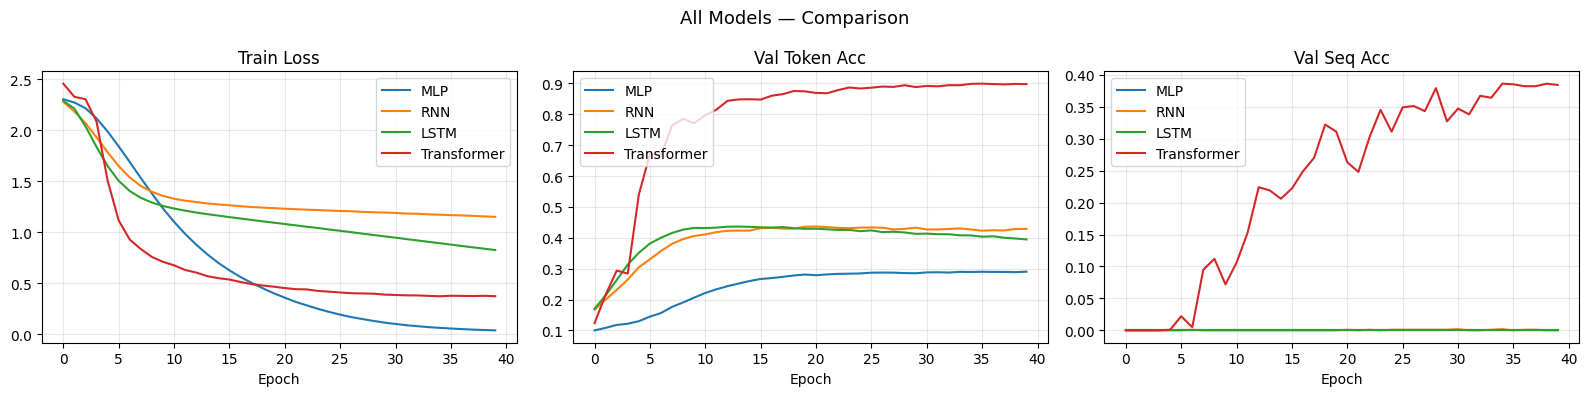

Model          |  tok_acc |  seq_acc
------------------------------------
MLP            |    0.279 |    0.000
RNN            |    0.421 |    0.000
LSTM           |    0.403 |    0.001
Transformer    |    0.897 |    0.379


In [15]:
all_hist = {"MLP": mlp_hist, "RNN": rnn_hist, "LSTM": lstm_hist, "Transformer": transformer_hist}
plot_histories(all_hist, title="All Models — Comparison")

print(f"{'Model':14s} | {'tok_acc':>8} | {'seq_acc':>8}")
print("-" * 36)
for name, model_ in [("MLP",mlp),("RNN",rnn),("LSTM",lstm),("Transformer",model)]:
    _, tok, seq = evaluate(model_, test_loader)
    print(f"{name:14s} | {tok:>8.3f} | {seq:>8.3f}")


## 6 · Attention Visualization

In [16]:
def visualize_attention(mdl, sequence, title=""):
    """Plot all layers × all heads for a single sequence."""
    mdl.eval()
    x = torch.tensor([sequence], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        _, all_weights = mdl(x, return_attn=True)

    n_layers = len(all_weights)
    n_heads  = all_weights[0].shape[1]
    labels   = [str(v) for v in sequence]

    fig, axes = plt.subplots(n_layers, n_heads, figsize=(4*n_heads, 4*n_layers))
    if n_layers == 1: axes = [axes]
    if n_heads  == 1: axes = [[ax] for ax in axes]

    for li, layer_w in enumerate(all_weights):
        w = layer_w[0].cpu().numpy()   # (H, T, T)
        for h in range(n_heads):
            ax = axes[li][h]
            sns.heatmap(w[h], ax=ax, cmap="Blues", vmin=0, vmax=1,
                        xticklabels=labels, yticklabels=labels,
                        linewidths=0.4, annot=True, fmt=".2f", annot_kws={"size": 7})
            ax.set_title(f"L{li} H{h}", fontsize=10)
            ax.set_xlabel("Key"); ax.set_ylabel("Query")

    plt.suptitle(f"{title} Attention Weights", fontsize=13)
    plt.tight_layout(); plt.show()


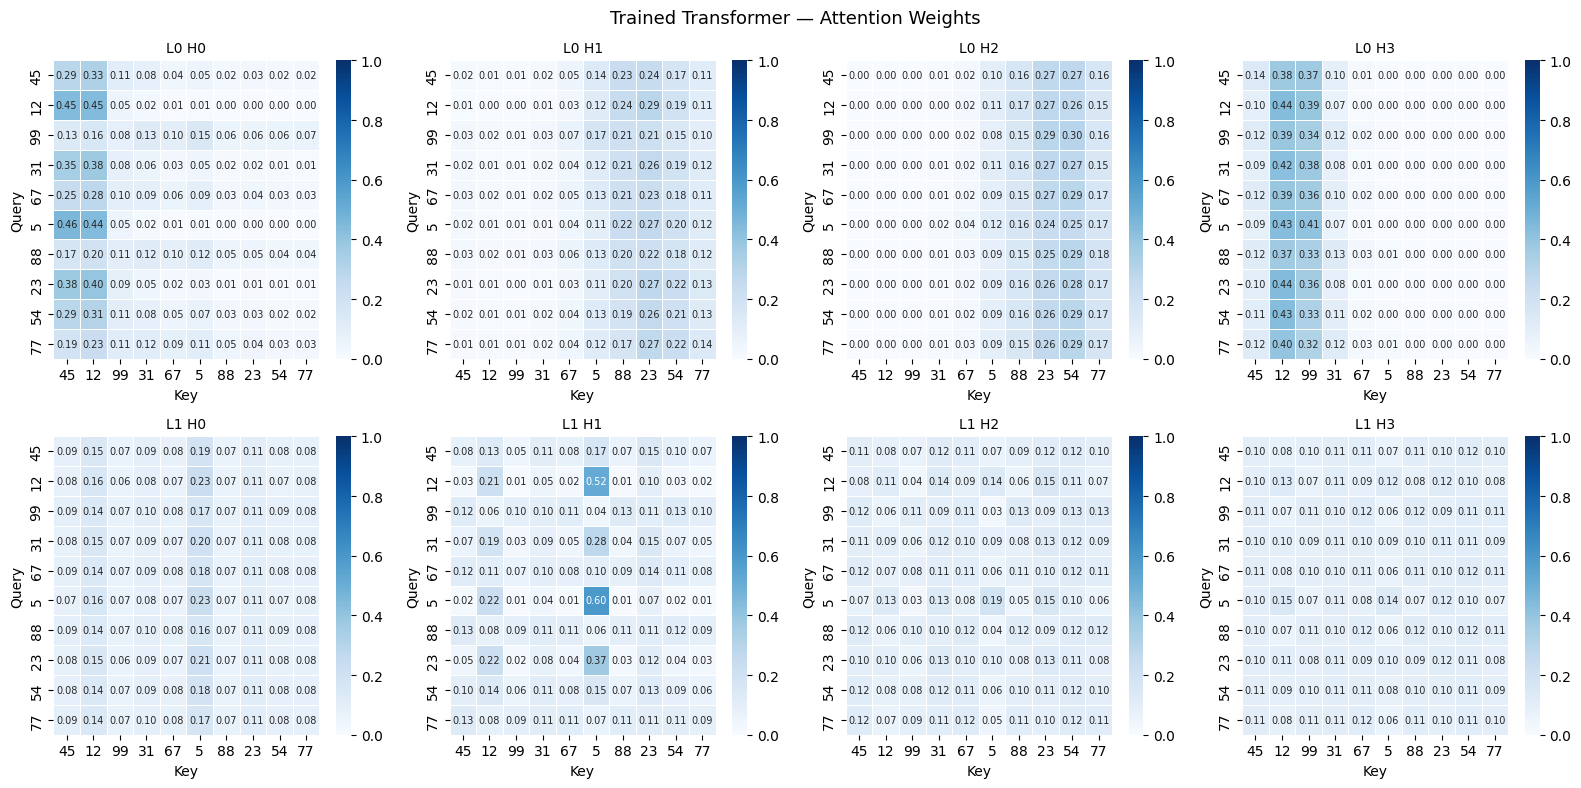

In [17]:
example_seq = [45, 12, 99, 31, 67, 5, 88, 23, 54, 77]
visualize_attention(model, example_seq, title="Trained Transformer —")


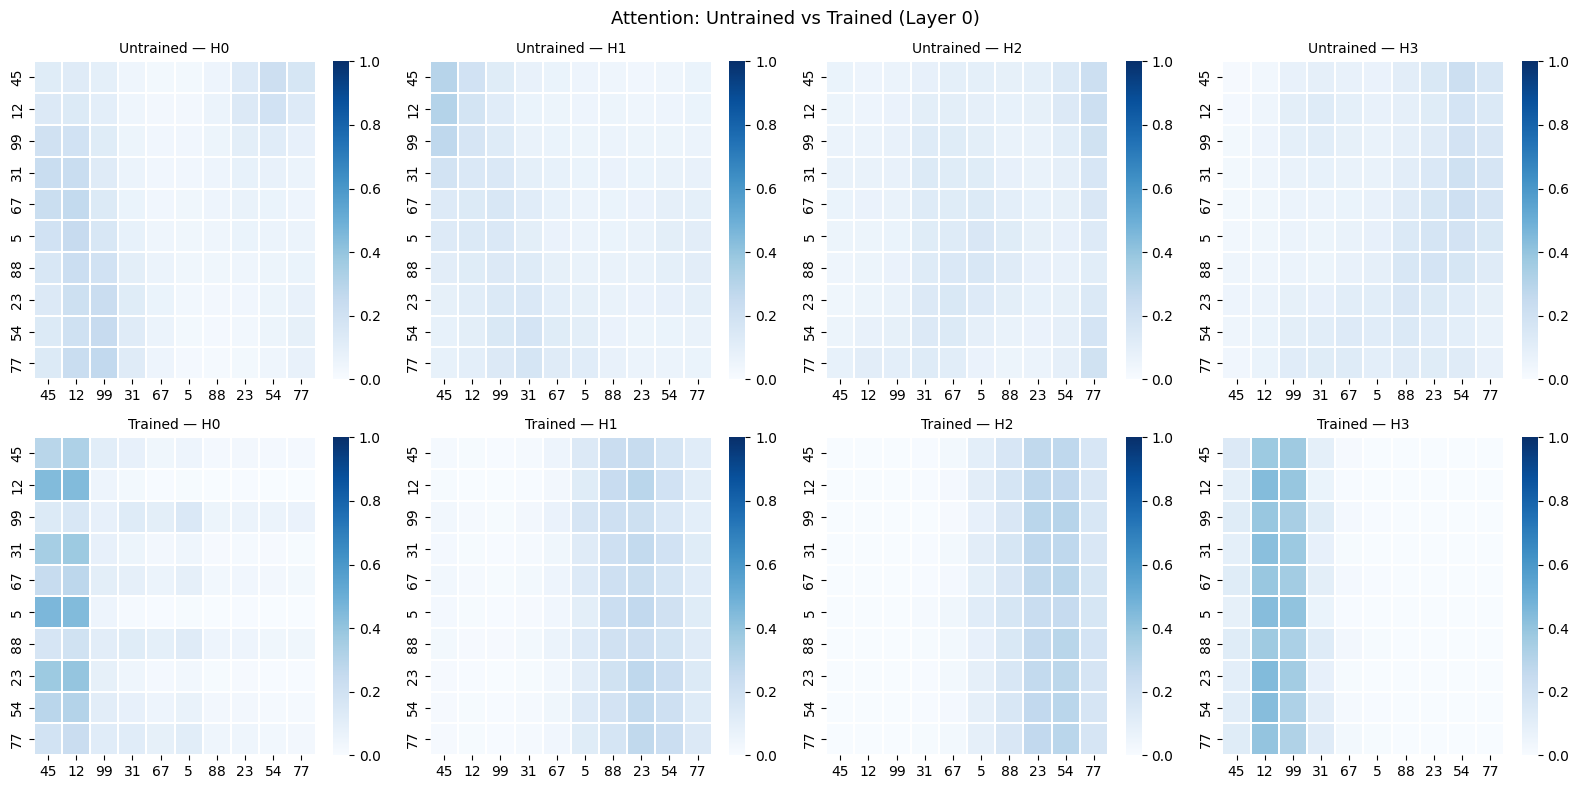

In [18]:
# ── Before vs After training ──────────────────────────────────────────────────
fresh = TransformerRanker().to(DEVICE)   # untrained

fig, axes = plt.subplots(2, N_HEADS, figsize=(4*N_HEADS, 8))
labels = [str(v) for v in example_seq]
x_ex   = torch.tensor([example_seq], dtype=torch.long).to(DEVICE)

for row, (title_, mdl_) in enumerate([("Untrained", fresh), ("Trained", model)]):
    mdl_.eval()
    with torch.no_grad():
        _, ws = mdl_(x_ex, return_attn=True)
    w = ws[0][0].cpu().numpy()   # layer 0
    for h in range(N_HEADS):
        ax = axes[row][h]
        sns.heatmap(w[h], ax=ax, cmap="Blues", vmin=0, vmax=1,
                    xticklabels=labels, yticklabels=labels, linewidths=.3)
        ax.set_title(f"{title_} — H{h}", fontsize=10)

plt.suptitle("Attention: Untrained vs Trained (Layer 0)", fontsize=13)
plt.tight_layout(); plt.show()


In [19]:
# ── Interactive inference ─────────────────────────────────────────────────────
@torch.no_grad()
def predict_ranks(sequence):
    model.eval()
    x = torch.tensor([sequence], dtype=torch.long).to(DEVICE)
    logits, _ = model(x, return_attn=True)
    preds = logits.argmax(-1)[0].cpu().tolist()
    true  = np.argsort(np.argsort(sequence)).tolist()
    print(f"Input      : {sequence}")
    print(f"Pred ranks : {preds}")
    print(f"True ranks : {true}")
    print(f"All correct: {preds == true}")

predict_ranks([45, 12, 99, 31, 67, 5, 88, 23, 54, 77])
predict_ranks([300, 100, 700, 500, 200, 900, 400, 800, 600, 50])


Input      : [45, 12, 99, 31, 67, 5, 88, 23, 54, 77]
Pred ranks : [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
True ranks : [4, 1, 9, 3, 6, 0, 8, 2, 5, 7]
All correct: False
Input      : [300, 100, 700, 500, 200, 900, 400, 800, 600, 50]
Pred ranks : [3, 1, 7, 5, 2, 9, 4, 8, 6, 0]
True ranks : [3, 1, 7, 5, 2, 9, 4, 8, 6, 0]
All correct: True


## 7 · Ablation Studies

### 7.1 · Positional Encoding


[PE=ON] Ep  10/40 | train=0.6388  val=0.4444  tok=0.823  seq=0.185
[PE=ON] Ep  20/40 | train=0.4477  val=0.2837  tok=0.882  seq=0.342
[PE=ON] Ep  30/40 | train=0.3821  val=0.2355  tok=0.905  seq=0.420
[PE=ON] Ep  40/40 | train=0.3679  val=0.2218  tok=0.912  seq=0.466
[PE=ON] Done in 10.4s
[PE=OFF] Ep  10/40 | train=0.3610  val=0.8640  tok=0.717  seq=0.067
[PE=OFF] Ep  20/40 | train=0.0929  val=1.3284  tok=0.737  seq=0.102
[PE=OFF] Ep  30/40 | train=0.0361  val=1.6985  tok=0.725  seq=0.090
[PE=OFF] Ep  40/40 | train=0.0285  val=1.7610  tok=0.726  seq=0.097
[PE=OFF] Done in 9.9s


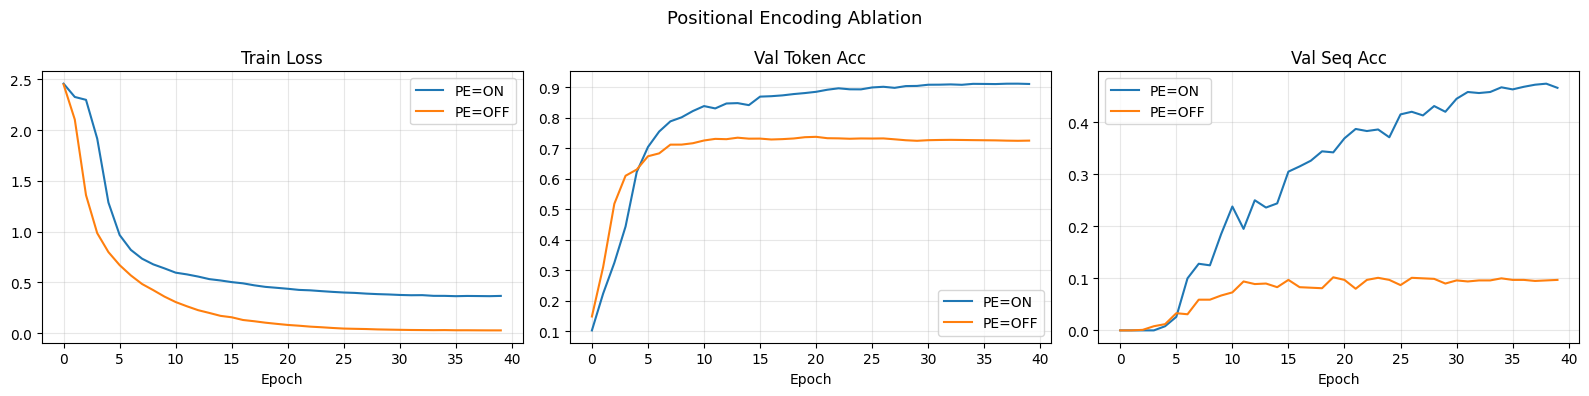

PE=ON   | tok=0.907  seq=0.455
PE=OFF  | tok=0.724  seq=0.107


In [20]:
pe_on  = TransformerRanker(use_pos_enc=True).to(DEVICE)
pe_off = TransformerRanker(use_pos_enc=False).to(DEVICE)
h_pe_on  = train_loop(pe_on,  "PE=ON")
h_pe_off = train_loop(pe_off, "PE=OFF")
plot_histories({"PE=ON": h_pe_on, "PE=OFF": h_pe_off}, "Positional Encoding Ablation")

_, pe_on_tok,  pe_on_seq  = evaluate(pe_on,  test_loader)
_, pe_off_tok, pe_off_seq = evaluate(pe_off, test_loader)
print(f"PE=ON   | tok={pe_on_tok:.3f}  seq={pe_on_seq:.3f}")
print(f"PE=OFF  | tok={pe_off_tok:.3f}  seq={pe_off_seq:.3f}")


### 7.2 · Encoder Depth (1 / 2 / 4 layers)

[1L] Ep  10/40 | train=1.0140  val=0.8551  tok=0.614  seq=0.007
[1L] Ep  20/40 | train=0.7684  val=0.6435  tok=0.716  seq=0.040
[1L] Ep  30/40 | train=0.6961  val=0.5857  tok=0.741  seq=0.039
[1L] Ep  40/40 | train=0.6777  val=0.5753  tok=0.749  seq=0.053
[1L] Done in 7.4s
[2L] Ep  10/40 | train=0.6861  val=0.4932  tok=0.800  seq=0.138
[2L] Ep  20/40 | train=0.4592  val=0.3070  tok=0.869  seq=0.288
[2L] Ep  30/40 | train=0.3827  val=0.2530  tok=0.896  seq=0.392
[2L] Ep  40/40 | train=0.3624  val=0.2402  tok=0.902  seq=0.404
[2L] Done in 10.4s
[4L] Ep  10/40 | train=0.6228  val=0.3841  tok=0.851  seq=0.245
[4L] Ep  20/40 | train=0.3297  val=0.1672  tok=0.941  seq=0.604
[4L] Ep  30/40 | train=0.2643  val=0.1360  tok=0.949  seq=0.667
[4L] Ep  40/40 | train=0.2504  val=0.1234  tok=0.958  seq=0.703
[4L] Done in 15.9s


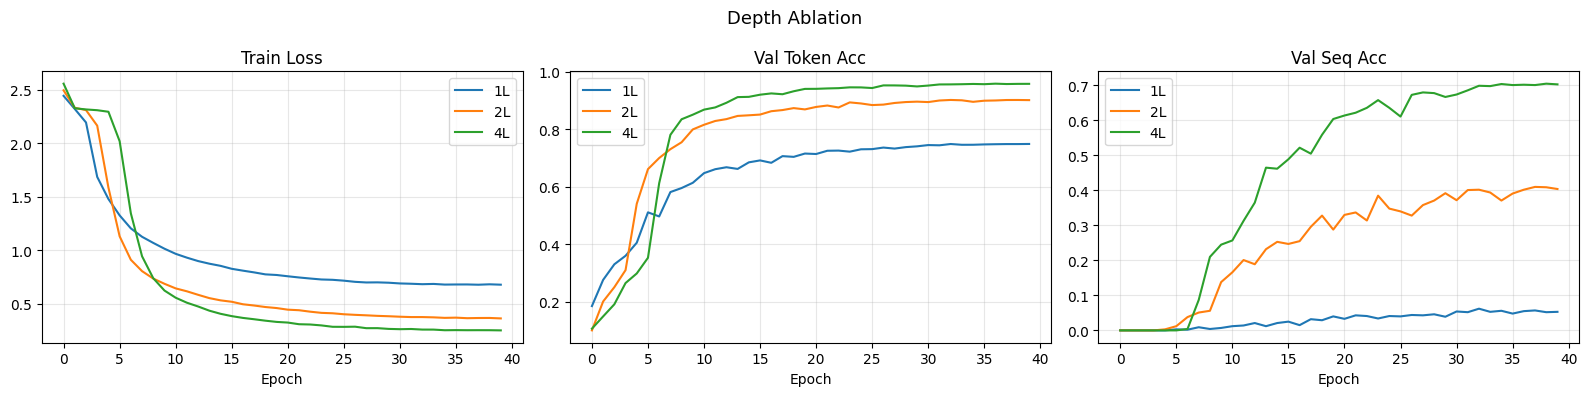


Test results:
  1 layers | tok=0.746  seq=0.055
  2 layers | tok=0.899  seq=0.393
  4 layers | tok=0.955  seq=0.691


In [21]:
depth_results = {}
for n_layers in [1, 2, 4]:
    m = TransformerRanker(n_layers=n_layers).to(DEVICE)
    h = train_loop(m, f"{n_layers}L")
    _, tok, seq = evaluate(m, test_loader)
    depth_results[n_layers] = {"history": h, "test_tok": tok, "test_seq": seq}

plot_histories({f"{n}L": r["history"] for n, r in depth_results.items()}, "Depth Ablation")
print("\nTest results:")
for n, r in depth_results.items():
    print(f"  {n} layers | tok={r['test_tok']:.3f}  seq={r['test_seq']:.3f}")


### 7.3 · Attention Head Count (1 / 2 / 4 / 8)

[1H] Ep  10/40 | train=0.7848  val=0.5971  tok=0.757  seq=0.058
[1H] Ep  20/40 | train=0.5949  val=0.4595  tok=0.813  seq=0.140
[1H] Ep  30/40 | train=0.5208  val=0.3826  tok=0.846  seq=0.224
[1H] Ep  40/40 | train=0.5042  val=0.3772  tok=0.846  seq=0.223
[1H] Done in 9.9s
[2H] Ep  10/40 | train=0.7386  val=0.5901  tok=0.752  seq=0.071
[2H] Ep  20/40 | train=0.5112  val=0.3857  tok=0.836  seq=0.168
[2H] Ep  30/40 | train=0.4424  val=0.3239  tok=0.861  seq=0.239
[2H] Ep  40/40 | train=0.4230  val=0.3137  tok=0.866  seq=0.254
[2H] Done in 10.4s
[4H] Ep  10/40 | train=0.7102  val=0.5215  tok=0.788  seq=0.119
[4H] Ep  20/40 | train=0.4778  val=0.3333  tok=0.866  seq=0.289
[4H] Ep  30/40 | train=0.4031  val=0.2629  tok=0.894  seq=0.400
[4H] Ep  40/40 | train=0.3848  val=0.2604  tok=0.892  seq=0.378
[4H] Done in 10.5s
[8H] Ep  10/40 | train=0.6750  val=0.5232  tok=0.786  seq=0.086
[8H] Ep  20/40 | train=0.4229  val=0.3081  tok=0.873  seq=0.267
[8H] Ep  30/40 | train=0.3583  val=0.2245  tok=0

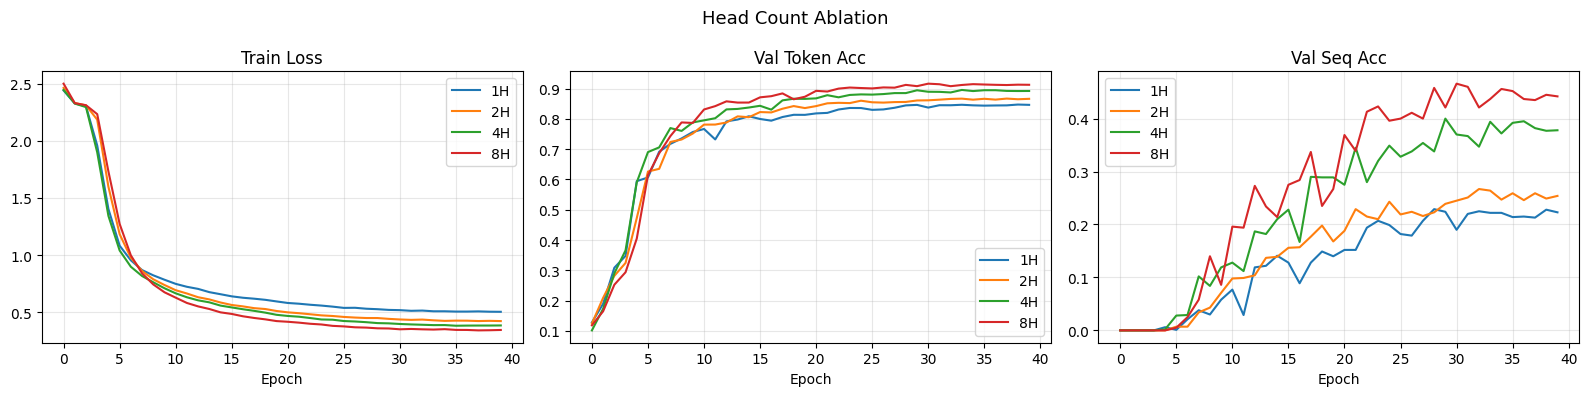


Test results:
  1 heads | tok=0.846  seq=0.224
  2 heads | tok=0.865  seq=0.250
  4 heads | tok=0.889  seq=0.361
  8 heads | tok=0.911  seq=0.455


In [22]:
head_results = {}
for n_heads in [1, 2, 4, 8]:
    m = TransformerRanker(n_heads=n_heads).to(DEVICE)
    h = train_loop(m, f"{n_heads}H")
    _, tok, seq = evaluate(m, test_loader)
    head_results[n_heads] = {"history": h, "test_tok": tok, "test_seq": seq}

plot_histories({f"{n}H": r["history"] for n, r in head_results.items()}, "Head Count Ablation")
print("\nTest results:")
for n, r in head_results.items():
    print(f"  {n} heads | tok={r['test_tok']:.3f}  seq={r['test_seq']:.3f}")


### 7.4 · Data Representation
Compare: **(a)** categorical embedding, **(b)** raw float projection, **(c)** sequence-normalized projection.

[Linear(raw)] Ep  10/40 | train=1.0142  val=0.9141  tok=0.606  seq=0.005
[Linear(raw)] Ep  20/40 | train=0.8081  val=0.8090  tok=0.651  seq=0.007
[Linear(raw)] Ep  30/40 | train=0.7595  val=0.7705  tok=0.666  seq=0.007
[Linear(raw)] Ep  40/40 | train=0.7490  val=0.7582  tok=0.671  seq=0.011
[Linear(raw)] Done in 10.2s
[Normalized] Ep  10/40 | train=0.5182  val=0.3558  tok=0.852  seq=0.173
[Normalized] Ep  20/40 | train=0.3742  val=0.2225  tok=0.912  seq=0.429
[Normalized] Ep  30/40 | train=0.3366  val=0.1999  tok=0.924  seq=0.483
[Normalized] Ep  40/40 | train=0.3260  val=0.1964  tok=0.924  seq=0.476
[Normalized] Done in 10.3s


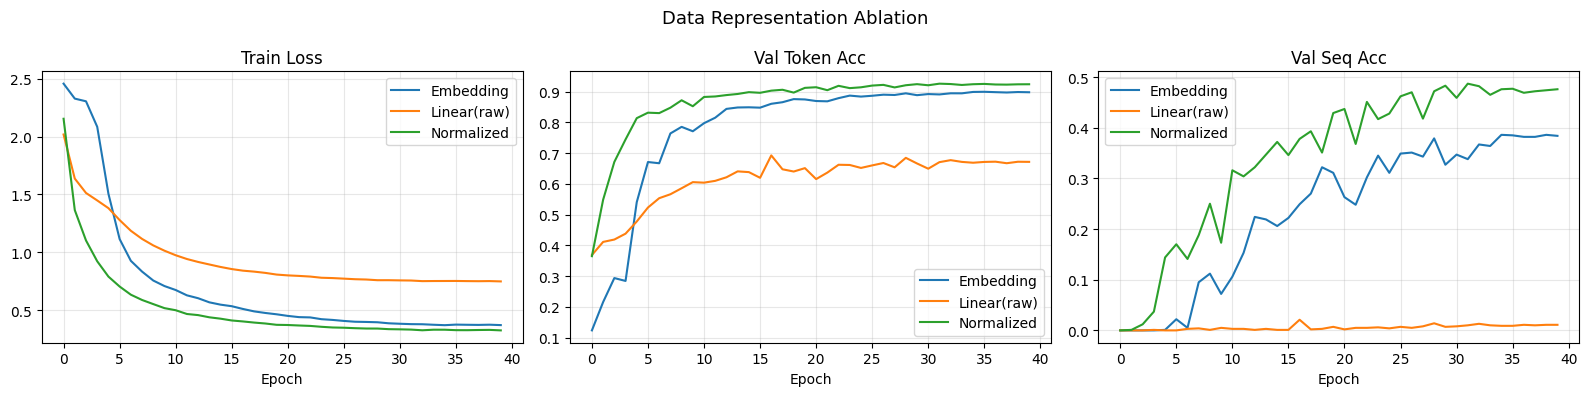

In [23]:
class TransformerRankerFloat(nn.Module):
    """Same architecture but takes float (B,T) input — for raw/normalized variants."""
    def __init__(self, seq_len=SEQ_LEN, d_model=D_MODEL, n_heads=N_HEADS,
                 n_layers=2, d_ff=D_FF, dropout=DROPOUT):
        super().__init__()
        self.embed   = nn.Linear(1, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        self.layers  = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout)
                                      for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, seq_len)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
    def forward(self, x):
        e = self.embed(x.float().unsqueeze(-1))
        e = self.pos_enc(e)
        for l in self.layers: e, _ = l(e)
        return self.head(self.norm(e))

def make_float_loader(X, y, normalize=False, shuffle=True):
    Xf = X.astype(np.float32)
    if normalize:
        Xf = (Xf - Xf.mean(axis=1, keepdims=True)) / (Xf.std(axis=1, keepdims=True) + 1e-8)
    ds = TensorDataset(torch.tensor(Xf), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

repr_results = {}

# (a) Categorical embedding — already trained
repr_results["Embedding"] = transformer_hist

# (b) Raw float
m_raw = TransformerRankerFloat().to(DEVICE)
h_raw = train_loop(m_raw, "Linear(raw)",
                   tl=make_float_loader(X_train, y_train),
                   vl=make_float_loader(X_val, y_val, shuffle=False))
repr_results["Linear(raw)"] = h_raw

# (c) Normalized
m_norm = TransformerRankerFloat().to(DEVICE)
h_norm = train_loop(m_norm, "Normalized",
                    tl=make_float_loader(X_train, y_train, normalize=True),
                    vl=make_float_loader(X_val, y_val, normalize=True, shuffle=False))
repr_results["Normalized"] = h_norm

plot_histories(repr_results, "Data Representation Ablation")


## 8 · Out-of-Distribution Evaluation

In [24]:
# Reload best transformer checkpoint
best = TransformerRanker().to(DEVICE)
best.load_state_dict(torch.load(os.path.join(BASE, "checkpoints", "transformer.pt"), map_location=DEVICE))
best.eval()

ood_names = ["ascending", "descending", "large_values", "negatives", "all_same"]
ood_results = {}

print(f"{'Set':15s} | {'tok_acc':>8} | {'seq_acc':>8}")
print("-" * 38)
for name in ood_names:
    Xo_raw = np.load(os.path.join(BASE, "data", f"ood_{name}_X.npy"))
    yo     = np.load(os.path.join(BASE, "data", f"ood_{name}_y.npy"))
    # Clamp values to valid embedding range [0, VOCAB-1].
    # OOD sets like 'large_values' (up to 10000) and 'negatives' (<0) are
    # outside the embedding table size (VOCAB=1000) and cause index errors.
    # Clamping preserves relative order so rank labels stay correct.
    Xo_clamped = np.clip(Xo_raw, 0, VOCAB - 1)
    Xo = torch.tensor(Xo_clamped, dtype=torch.long)
    yo = torch.tensor(yo,          dtype=torch.long)
    loader = DataLoader(TensorDataset(Xo, yo), batch_size=64)
    _, tok, seq = evaluate(best, loader)
    ood_results[name] = {"tok": tok, "seq": seq}
    print(f"{name:15s} | {tok:>8.3f} | {seq:>8.3f}")

_, id_tok, id_seq = evaluate(best, test_loader)
print(f"{'in-dist (test)':15s} | {id_tok:>8.3f} | {id_seq:>8.3f}")

Set             |  tok_acc |  seq_acc
--------------------------------------
ascending       |    0.100 |    0.000
descending      |    0.100 |    0.000
large_values    |    0.100 |    0.000
negatives       |    0.100 |    0.000
all_same        |    0.100 |    0.000
in-dist (test)  |    0.897 |    0.379


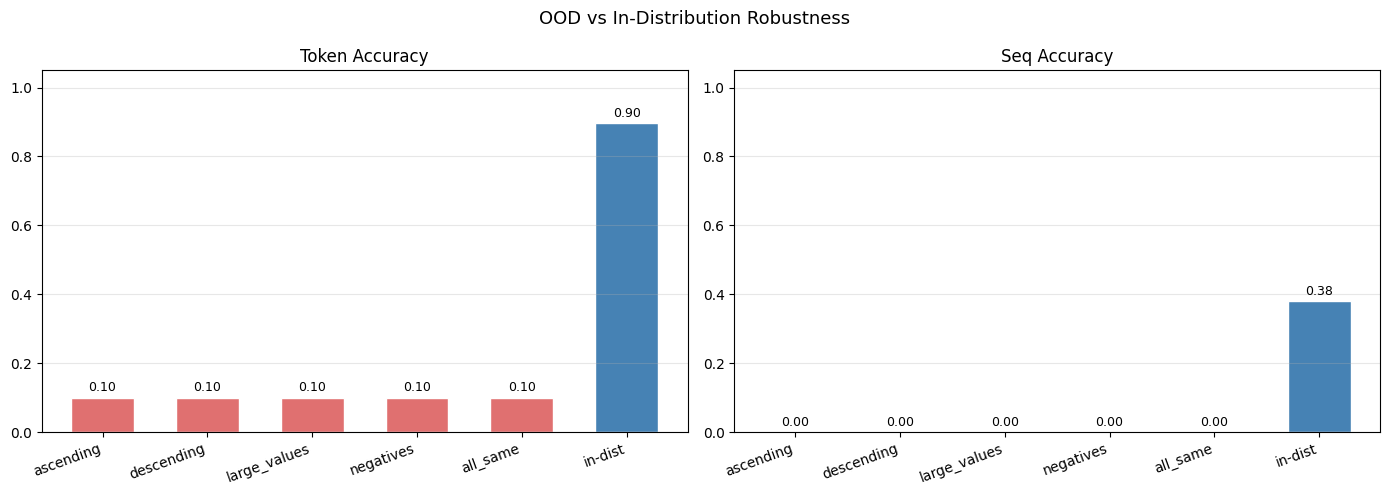

In [25]:
names    = ood_names + ["in-dist"]
tok_vals = [ood_results[n]["tok"] for n in ood_names] + [id_tok]
seq_vals = [ood_results[n]["seq"] for n in ood_names] + [id_seq]
bar_colors = ["#e07070"] * len(ood_names) + ["steelblue"]

x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title in zip(axes, [tok_vals, seq_vals], ["Token Accuracy", "Seq Accuracy"]):
    bars = ax.bar(x, vals, color=bar_colors, edgecolor="white", width=0.6)
    ax.set_title(title); ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)
plt.suptitle("OOD vs In-Distribution Robustness", fontsize=13)
plt.tight_layout(); plt.show()


Ascending sequence:


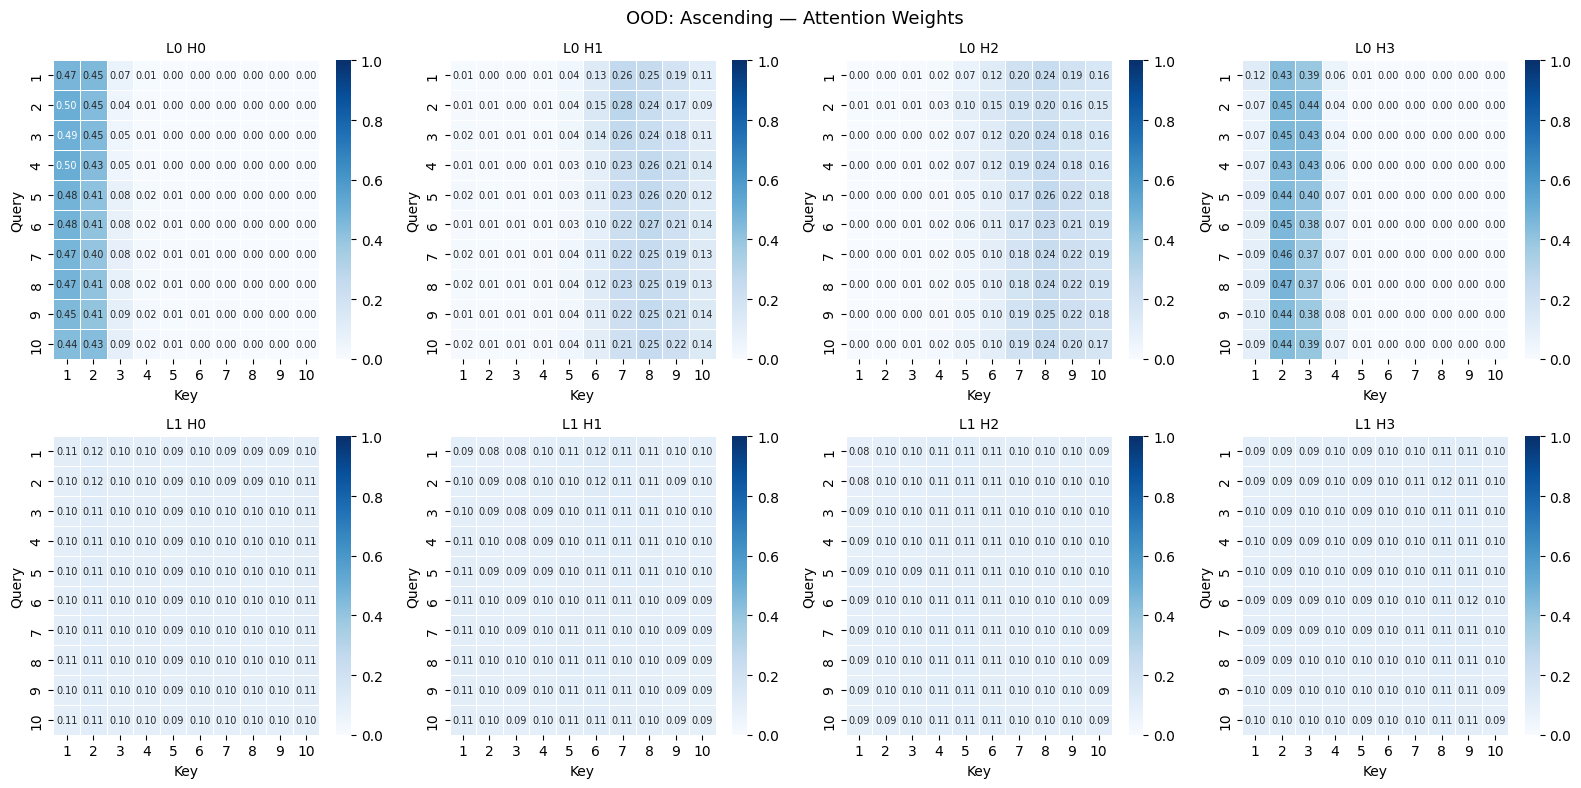

All-same sequence:


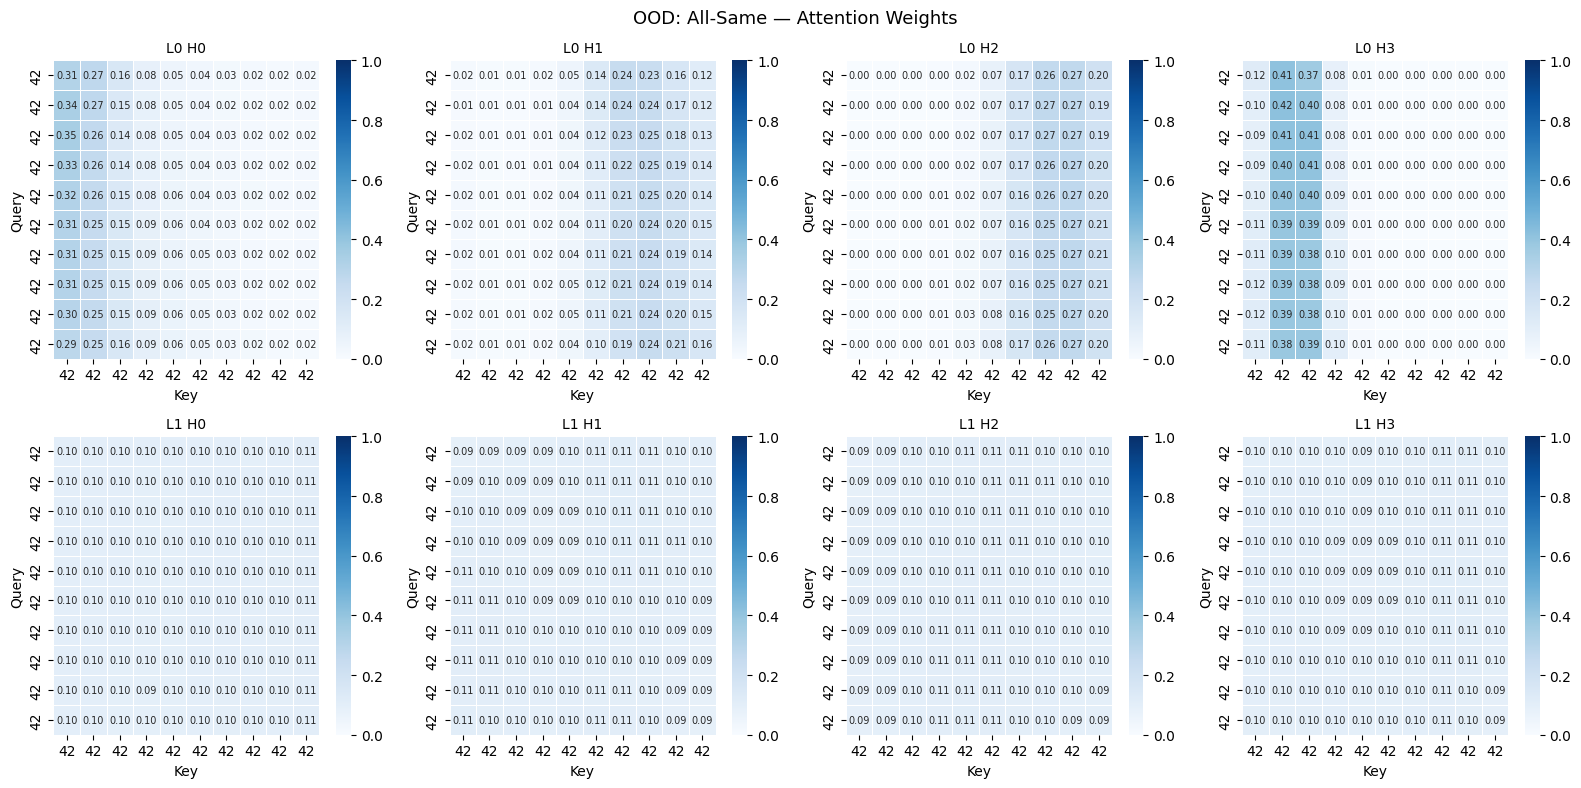

In [26]:
# ── Attention on OOD examples ─────────────────────────────────────────────────
print("Ascending sequence:")
visualize_attention(best, list(range(1, SEQ_LEN+1)), title="OOD: Ascending —")

print("All-same sequence:")
visualize_attention(best, [42]*SEQ_LEN, title="OOD: All-Same —")


## 9 · Summary Table

In [27]:
summary = {}

# Baselines
for name, model_ in [("MLP", mlp), ("RNN", rnn), ("LSTM", lstm)]:
    _, tok, seq = evaluate(model_, test_loader)
    summary[name] = {"tok_acc": tok, "seq_acc": seq, "type": "baseline"}

# Transformer
_, tok, seq = evaluate(model, test_loader)
summary["Transformer (2L 4H)"] = {"tok_acc": tok, "seq_acc": seq, "type": "transformer"}

# Ablations
summary["PE=ON"]  = {"tok_acc": pe_on_tok,  "seq_acc": pe_on_seq,  "type": "ablation"}
summary["PE=OFF"] = {"tok_acc": pe_off_tok, "seq_acc": pe_off_seq, "type": "ablation"}
for n, r in depth_results.items():
    summary[f"Depth {n}L"] = {"tok_acc": r["test_tok"], "seq_acc": r["test_seq"], "type": "ablation"}
for n, r in head_results.items():
    summary[f"{n} Heads"] = {"tok_acc": r["test_tok"], "seq_acc": r["test_seq"], "type": "ablation"}

print(f"{'Config':22s} | {'Type':12s} | {'Tok Acc':>8} | {'Seq Acc':>8}")
print("-" * 60)
for k, v in summary.items():
    print(f"{k:22s} | {v['type']:12s} | {v['tok_acc']:>8.3f} | {v['seq_acc']:>8.3f}")

with open(os.path.join(BASE, "checkpoints", "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("\nSummary saved to", os.path.join(BASE, "checkpoints", "summary.json"))


Config                 | Type         |  Tok Acc |  Seq Acc
------------------------------------------------------------
MLP                    | baseline     |    0.279 |    0.000
RNN                    | baseline     |    0.421 |    0.000
LSTM                   | baseline     |    0.403 |    0.001
Transformer (2L 4H)    | transformer  |    0.897 |    0.379
PE=ON                  | ablation     |    0.907 |    0.455
PE=OFF                 | ablation     |    0.724 |    0.107
Depth 1L               | ablation     |    0.746 |    0.055
Depth 2L               | ablation     |    0.899 |    0.393
Depth 4L               | ablation     |    0.955 |    0.691
1 Heads                | ablation     |    0.846 |    0.224
2 Heads                | ablation     |    0.865 |    0.250
4 Heads                | ablation     |    0.889 |    0.361
8 Heads                | ablation     |    0.911 |    0.455

Summary saved to /content/ranking_project/checkpoints/summary.json
